# Medical Cost Prediction Using Machine Learning Regression

## Objective

The objective of this project is to predict individual medical insurance expenses using machine learning regression techniques.

Input features:

- Age
- Sex
- BMI
- Number of children
- Smoking status
- Region

Target variable:

- Charges

Since the target variable consists of continuous numerical values, this problem belongs to supervised learning and regression analysis.

Multiple regression models will be implemented and evaluated using different performance metrics.

# Table of Contents

1. Introduction
2. Import Libraries
3. Load Dataset
4. Exploratory Data Analysis
5. Data Preprocessing
6. Train-Test Split
7. Linear Regression
8. Decision Tree Regressor
9. Random Forest Regressor
10. Model Comparison
11. Feature Importance Analysis
12. Discussion and Considerations
13. Ingenuity Points
14. Future Improvements
15. Conclusion

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

The Medical Cost Personal Dataset is loaded using Pandas. The first few rows are displayed to understand the structure of the dataset.

In [58]:
# Load the dataset
df = pd.read_csv("insurance.csv")

In [59]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [60]:
df.shape

(1338, 7)

In [61]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the structure, distribution, and characteristics of the dataset before building machine learning models.

In [62]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [63]:
# Statistical summary
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [64]:
# Check missing values
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

## Distribution of Numerical Features

Histograms are used to understand the distribution of numerical variables in the dataset.

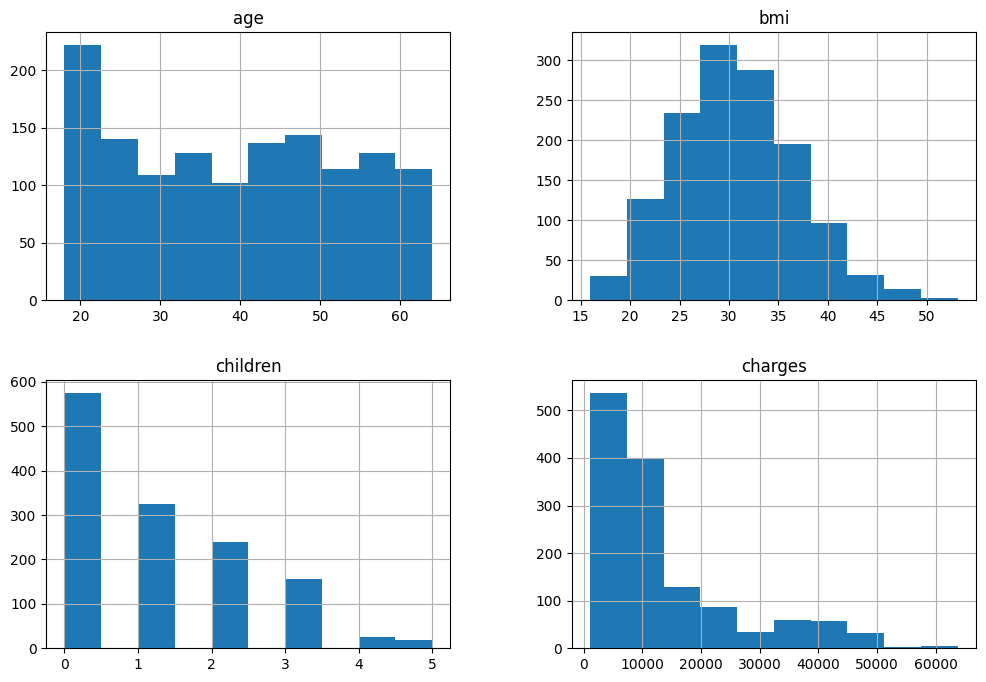

In [65]:
# Histograms of numerical features
df.hist(figsize=(12, 8))
plt.show()

## Distribution of Charges

The distribution of the target variable (charges) is analyzed.

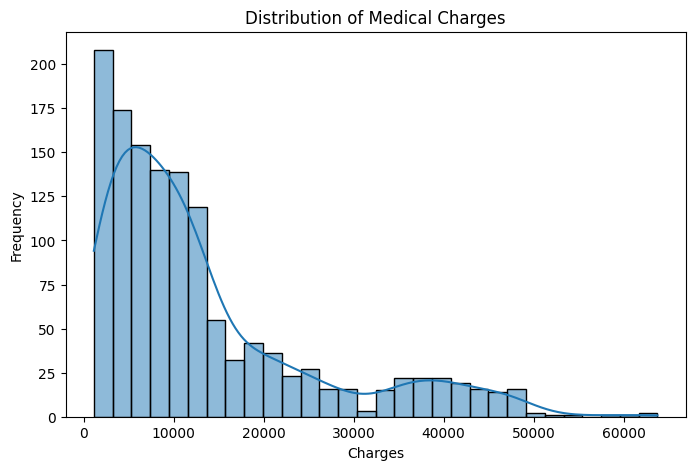

In [66]:
plt.figure(figsize=(8,5))
sns.histplot(df['charges'], bins=30, kde=True)

plt.title("Distribution of Medical Charges")
plt.xlabel("Charges")
plt.ylabel("Frequency")

plt.show()

## Correlation Analysis

A heatmap is used to visualize the relationships among numerical features.

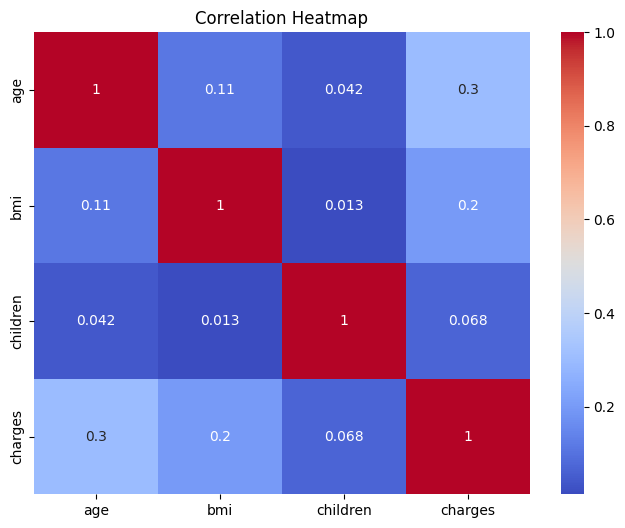

In [67]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

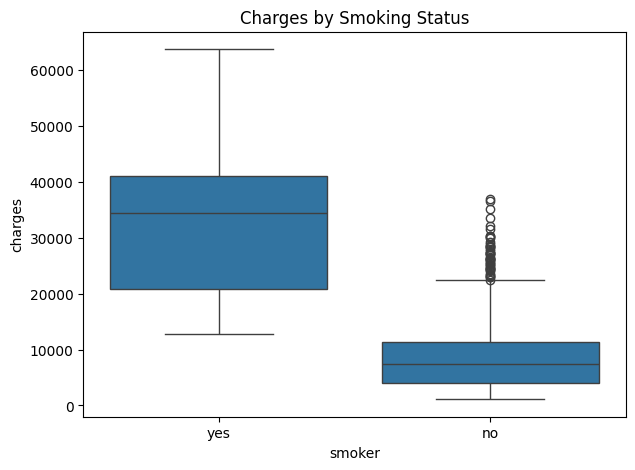

In [68]:
plt.figure(figsize=(7,5))

sns.boxplot(x='smoker',
            y='charges',
            data=df)

plt.title("Charges by Smoking Status")

plt.show()

# Data Preprocessing

Categorical variables are converted into numerical representations, and the input features and target variable are separated.

In [69]:
# Features
X = df.drop('charges', axis=1)

# Target
y = df['charges']

In [70]:
X.head()

,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest


In [71]:
y.head()

0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64

In [72]:
# Numerical columns
numerical_features = ['age', 'bmi', 'children']

# Categorical columns
categorical_features = ['sex', 'smoker', 'region']

In [73]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [74]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'),
         categorical_features)
    ],
    remainder='passthrough'
)

In [75]:
X_processed = preprocessor.fit_transform(X)

In [76]:
X_processed.shape

(1338, 8)

# Train-Test Split

The dataset is divided into training and testing sets. The training set is used to train the machine learning model, while the testing set is used to evaluate its performance on unseen data.

In [77]:
from sklearn.model_selection import train_test_split

In [78]:
X_train, X_test, y_train, y_test = train_test_split(
    X_processed,
    y,
    test_size=0.2,
    random_state=42
)

In [79]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_processed,
    y,
    test_size=0.2,
    random_state=42
)

In [80]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1070, 8)
X_test shape: (268, 8)
y_train shape: (1070,)
y_test shape: (268,)


# Project Workflow

Dataset

⬇

Exploratory Data Analysis (EDA)

⬇

Data Preprocessing

⬇

Train-Test Split

⬇

Linear Regression

⬇

Decision Tree Regressor

⬇

Random Forest Regressor

⬇

Model Evaluation

⬇

Model Comparison

⬇

Feature Importance Analysis

⬇

Discussion and Conclusion

# Linear Regression

Linear Regression is implemented as the baseline regression model. Its performance is evaluated using several regression metrics.

In [81]:
from sklearn.linear_model import LinearRegression

In [82]:
linear_model = LinearRegression()

In [83]:
import sklearn
print(sklearn.__version__)

1.6.1


In [84]:
linear_model.fit(X_train, y_train)

LinearRegression()

In [85]:
print(y_pred_lr[:10])

[ 8969.55027444  7068.74744287 36858.41091155  9454.67850053
 26973.17345656 10864.11316424   170.28084136 16903.45028662
  1092.43093614 11218.34318352]


# Model Evaluation

The performance of the Linear Regression model is evaluated using several regression metrics.

In [86]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [87]:
# Calculate evaluation metrics
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

In [88]:
print("Linear Regression Performance")
print("-----------------------------")
print("MAE :", mae_lr)
print("MSE :", mse_lr)
print("RMSE:", rmse_lr)
print("R² Score:", r2_lr)

Linear Regression Performance
-----------------------------
MAE : 4181.194473753624
MSE : 33596915.851361394
RMSE: 5796.284659276267
R² Score: 0.7835929767120727


# Decision Tree Regressor

Decision Tree Regressor was implemented to capture nonlinear relationships among features and medical expenses. Unlike Linear Regression, Decision Trees do not assume a linear relationship between variables.

In [89]:
from sklearn.tree import DecisionTreeRegressor

In [90]:
dt_model = DecisionTreeRegressor(random_state=42)

In [91]:
dt_model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [92]:
y_pred_dt = dt_model.predict(X_test)

In [93]:
print(y_pred_dt[:10])

[ 8615.3      5266.3656  28950.4692   9225.2564  33732.6867  11326.71487
  2527.81865 14410.9321   2974.126   10702.6424 ]


# Decision Tree Evaluation

The performance of the Decision Tree Regressor is evaluated using several regression metrics.

In [94]:
# Calculate evaluation metrics for Decision Tree
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)

In [95]:
print("Decision Tree Performance")
print("-------------------------")
print("MAE :", mae_dt)
print("MSE :", mse_dt)
print("RMSE:", rmse_dt)
print("R² Score:", r2_dt)

Decision Tree Performance
-------------------------
MAE : 3195.1104733805973
MSE : 42446908.010150984
RMSE: 6515.129162967606
R² Score: 0.7265877305258355


# Random Forest Regressor

Random Forest Regressor was implemented to improve prediction performance through ensemble learning. By combining multiple decision trees, Random Forest reduces overfitting and provides more robust predictions.

In [96]:
from sklearn.ensemble import RandomForestRegressor

In [97]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [98]:
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [99]:
y_pred_rf = rf_model.predict(X_test)

In [100]:
print(y_pred_rf[:10])

[ 9627.2160164  5567.6616345 28239.6470855 12462.6824866 34640.8607121
  8208.8969818  2080.942686  14571.0440277  5457.1696048 10791.9984202]


# Random Forest Evaluation

The Random Forest Regressor is evaluated using multiple regression metrics to assess its prediction performance.

In [101]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("-------------------------")
print("MAE :", mae_rf)
print("MSE :", mse_rf)
print("RMSE:", rmse_rf)
print("R² Score:", r2_rf)

Random Forest Performance
-------------------------
MAE : 2550.528290077554
MSE : 20938397.35715491
RMSE: 4575.849359097709
R² Score: 0.8651299939396644


# Model Comparison Visualization

The performance of different regression models is compared using the R² score. Higher values indicate better prediction accuracy.

In [103]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression',
              'Decision Tree',
              'Random Forest'],
    
    'MAE': [mae_lr,
            mae_dt,
            mae_rf],
    
    'RMSE': [rmse_lr,
             rmse_dt,
             rmse_rf],
    
    'R² Score': [r2_lr,
                 r2_dt,
                 r2_rf]
})

comparison

,Model,MAE,RMSE,R² Score
0,Linear Regression,4181.194474,5796.284659,0.783593
1,Decision Tree,3195.110473,6515.129163,0.726588
2,Random Forest,2550.528290,4575.849359,0.865130


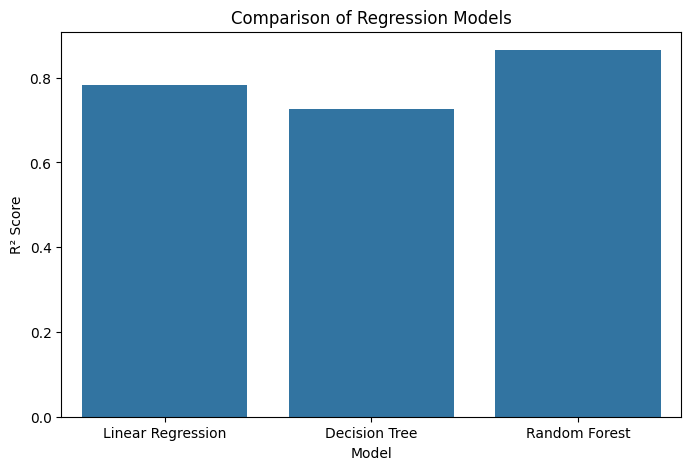

In [104]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='R² Score',
    data=comparison
)

plt.title('Comparison of Regression Models')
plt.ylabel('R² Score')
plt.xlabel('Model')

plt.show()

# Feature Importance Analysis

Feature importance analysis is performed using the Random Forest Regressor to identify which input variables contribute most to predicting medical insurance charges.

Understanding feature importance helps interpret the model and provides insights into the factors that have the greatest impact on medical expenses.

In [51]:
# Feature importance values
importance = rf_model.feature_importances_

print(importance)

[0.00629218 0.60861836 0.00561094 0.00527715 0.00393515 0.13412949
 0.21671389 0.01942283]


In [52]:
# Get encoded feature names
feature_names = preprocessor.get_feature_names_out()

print(feature_names)

['cat__sex_male' 'cat__smoker_yes' 'cat__region_northwest'
 'cat__region_southeast' 'cat__region_southwest' 'remainder__age'
 'remainder__bmi' 'remainder__children']


In [53]:
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

feature_importance_df

,Feature,Importance
0,cat__sex_male,0.006292
1,cat__smoker_yes,0.608618
2,cat__region_northwest,0.005611
3,cat__region_southeast,0.005277
4,cat__region_southwest,0.003935
5,remainder__age,0.134129
6,remainder__bmi,0.216714
7,remainder__children,0.019423


In [54]:
feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

feature_importance_df

,Feature,Importance
1,cat__smoker_yes,0.608618
6,remainder__bmi,0.216714
5,remainder__age,0.134129
7,remainder__children,0.019423
0,cat__sex_male,0.006292
2,cat__region_northwest,0.005611
3,cat__region_southeast,0.005277
4,cat__region_southwest,0.003935


# Feature Importance Visualization

The feature importance scores are visualized to compare the contribution of different variables. Features with higher importance values have a greater impact on predicting medical insurance charges.

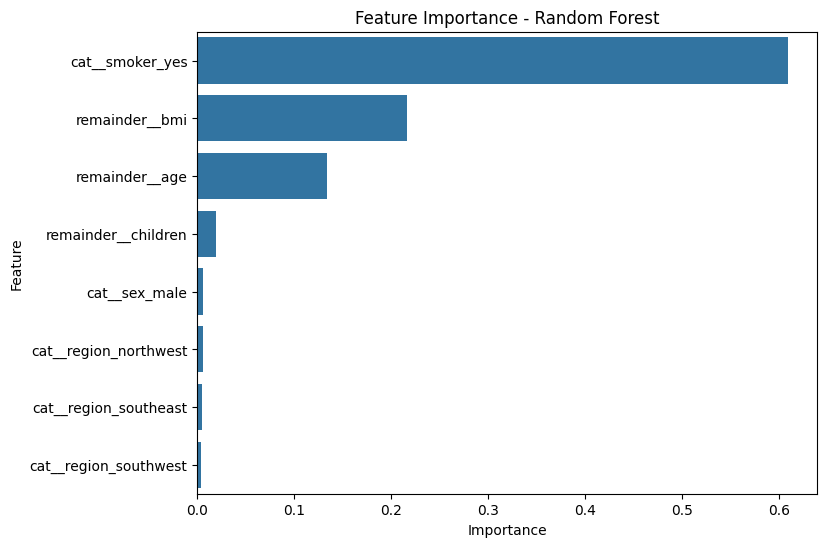

In [55]:
plt.figure(figsize=(8,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df
)

plt.title('Feature Importance - Random Forest')

plt.show()

# Discussion and Considerations

Several observations were obtained from the experimental results.

- The target variable (charges) exhibited a right-skewed distribution, indicating that a small number of individuals incur significantly higher medical expenses.

- Correlation analysis showed that age and BMI have positive relationships with medical expenses.

- Smoking status had the strongest influence on insurance charges, which was confirmed through feature importance analysis.

- Linear Regression provided a simple and interpretable baseline model. However, it assumes linear relationships and may not capture complex interactions among variables.

- Decision Tree Regressor was able to capture nonlinear relationships but showed signs of overfitting due to its high flexibility.

- Random Forest Regressor achieved the best overall performance because ensemble learning reduces overfitting and improves prediction accuracy.

- Feature importance analysis revealed that smoking status, age, and BMI were the most influential variables affecting medical expenses.

These findings are consistent with real-world expectations and demonstrate the effectiveness of machine learning techniques for regression problems.

# Ingenuity Points

The following improvements were incorporated into this study:

1. Exploratory Data Analysis (EDA) was performed to understand the characteristics and distributions of the dataset.

2. One-Hot Encoding was applied to categorical variables to enable machine learning algorithms to process them.

3. Three regression algorithms were implemented and compared:
   - Linear Regression
   - Decision Tree Regressor
   - Random Forest Regressor

4. Multiple evaluation metrics (MAE, MSE, RMSE, and R² score) were used to assess model performance objectively.

5. Feature importance analysis was performed using Random Forest to identify the most influential variables affecting medical expenses.

6. Visualization techniques such as histograms, heatmaps, boxplots, and feature importance plots were used to improve interpretability.

These improvements enhanced both the predictive performance and interpretability of the models.

# Conclusion

In this study, machine learning regression techniques were applied to predict individual medical insurance expenses.

Three regression models were implemented and evaluated:

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor

Among these models, Random Forest Regressor achieved the best performance. Ensemble learning enabled the model to capture nonlinear relationships and reduce overfitting, resulting in improved prediction accuracy.

Feature importance analysis showed that smoking status, age, and BMI were the most important factors influencing medical expenses.

This study demonstrates the importance of data preprocessing, model comparison, and interpretability in machine learning-based regression tasks.